In [2]:
import pandas as pd

# Read your Excel file
df = pd.read_excel('/Users/ds39/Documents/Sunny/MAVE/RD/concentration/250402_AllTargetonlist_quantification_revalues.xlsx', engine='openpyxl')

# Optionally, if you have merged cells that need to be filled:
df.fillna(method='ffill', inplace=True)

# Now you can inspect the DataFrame
print(list(df.columns))

['Targeton Name', 'Gene', 'Screen ID', 'Hdr Vector Lot', 'HDR_nanodrop (ng/ul)', 'HDR_A260/A280', 'HDR_A260/A230', 'Qubit(ng/ul)', 'HDR_actual_DNA', 'gRNA Vector Lot', 'gRNA_nanodrop (ng/ul)', 'gRNA_A260/A280', 'gRNA_A260/A230', 'gRNA_Qubit (ng/ul)', 'gRNA_actual_DNA', 'Per_Million_TotalDNA', 'D4R1 Mapped Reads', 'D4R2 Mapped Reads', 'D4R2 Mapped Reads.1', 'Average_mapped_reads', 'Comment']


/var/folders/88/r4q5_g595xs0mq3119k4nxy40000gq/T/ipykernel_66230/2945394488.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


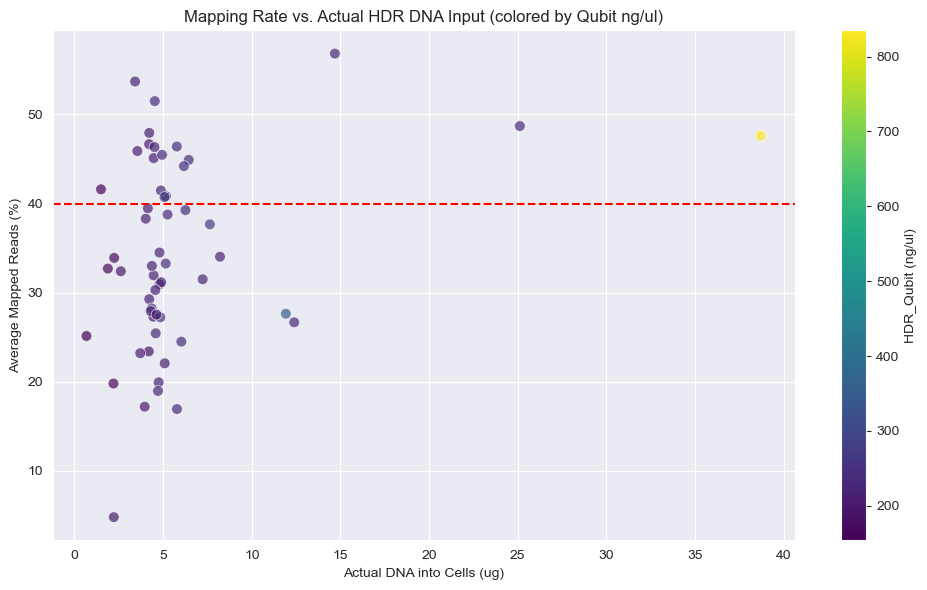

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
ax = plt.gca()  # Get the current Axes

# Create the scatter plot using Seaborn; disable the automatic legend for hue
sns.scatterplot(
    data=filtered_df,
    x='gRNA_Actual_ug_into_cells',
    y='average_Mapped_reads',
    hue='gRNA_Qubit Re-quant (ng/ul)',           # Use A260/A280 as a continuous variable for coloring
    palette='viridis',
    legend=False,              # Disable the default legend
    alpha=0.7,
    s=60                      # Marker size; adjust as needed
)

# Add a horizontal line to mark the 40% mapped rate threshold
plt.axhline(40, color='red', linestyle='--', label='40% Mapped Rate')

plt.xlabel("Actual DNA into Cells (ug)")
plt.ylabel("Average Mapped Reads (%)")
plt.title("Mapping Rate vs. Actual HDR DNA Input (colored by Qubit ng/ul)")

# Create a colorbar as a continuous legend for A260/A280 values
norm = plt.Normalize(filtered_df['HDR_Qubit Re-quant (ng/ul)'].min(), filtered_df['HDR_Qubit Re-quant (ng/ul)'].max())
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])

# Pass the current Axes (ax) to the colorbar
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('HDR_Qubit (ng/ul)')

plt.tight_layout()
plt.show()



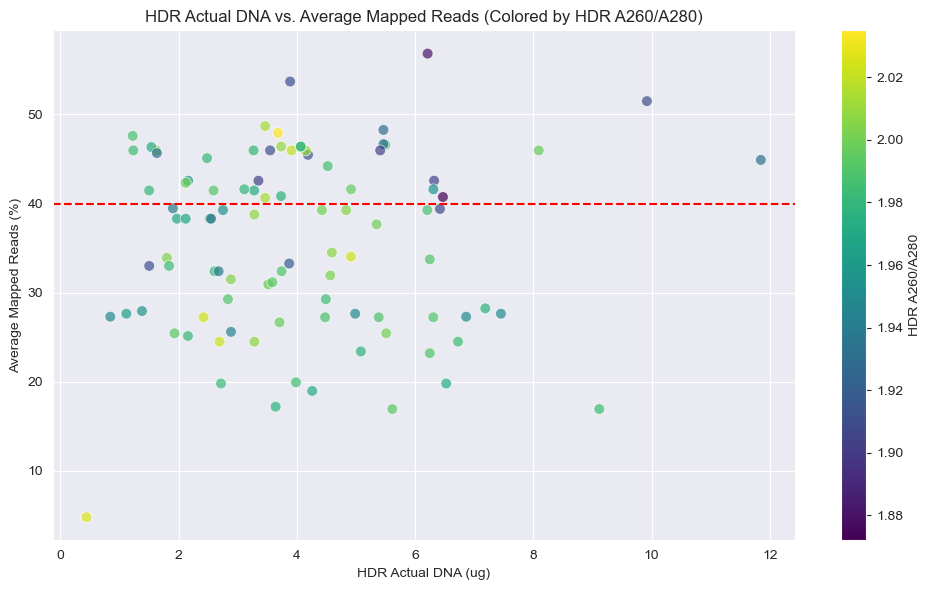

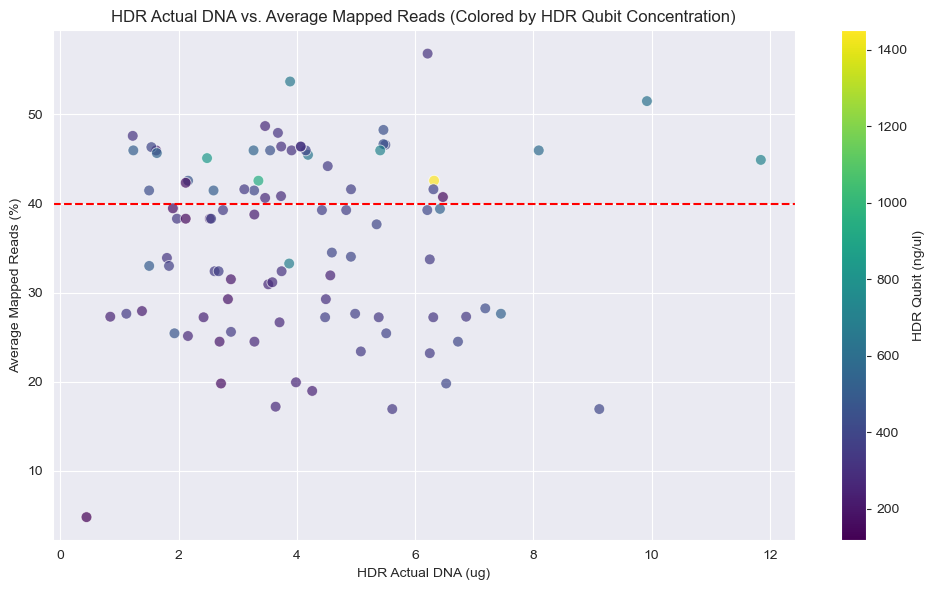

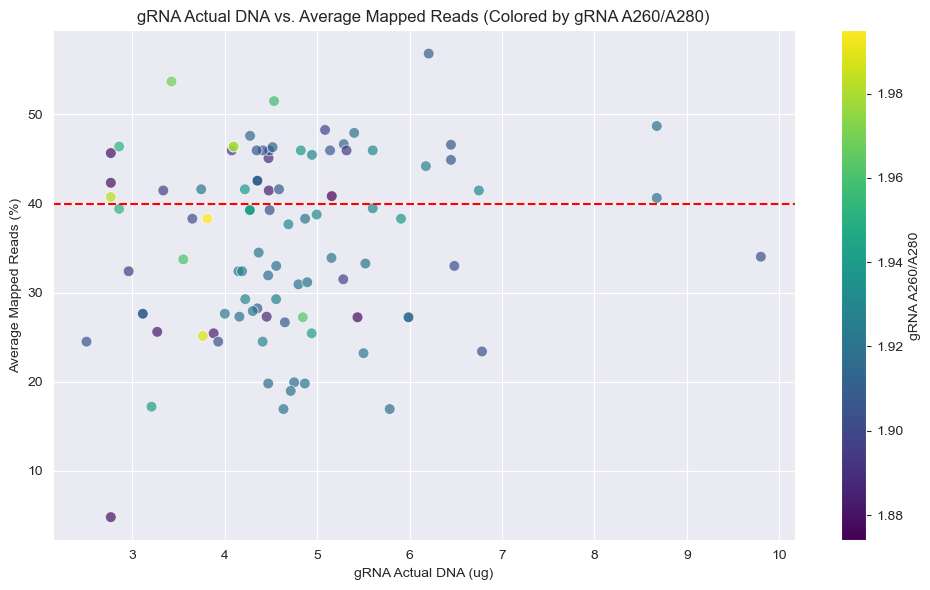

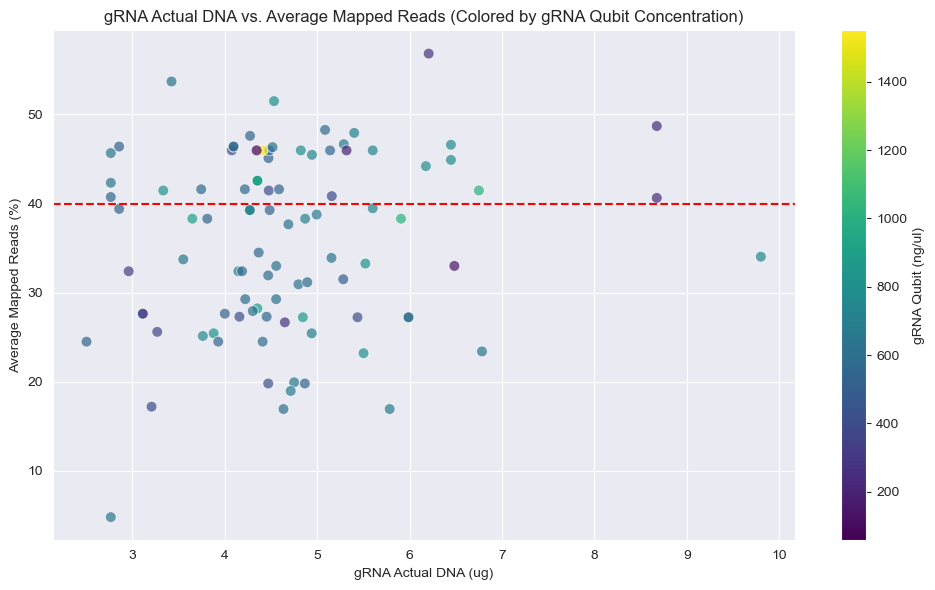

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import cm

# Drop rows with missing average mapped reads
filtered_df = df.dropna(subset=['Average_mapped_reads'])

# Separate HDR and gRNA data
filtered_hdr_df = filtered_df.dropna(subset=['HDR_actual_DNA', 'HDR_A260/A280', 'Qubit(ng/ul)'])
filtered_grna_df = filtered_df.dropna(subset=['gRNA_actual_DNA', 'gRNA_A260/A280', 'gRNA_Qubit (ng/ul)'])

# Plot 1: HDR Actual DNA vs Average Mapped Reads (Colored by HDR A260/A280)
plt.figure(figsize=(10, 6))
ax = plt.gca()
sns.scatterplot(
    data=filtered_hdr_df,
    x='HDR_actual_DNA',
    y='Average_mapped_reads',
    hue='HDR_A260/A280',
    palette='viridis',
    legend=False,
    alpha=0.7,
    s=60
)
plt.axhline(40, color='red', linestyle='--', label='40% Mapped Rate')
plt.title("HDR Actual DNA vs. Average Mapped Reads (Colored by HDR A260/A280)")
plt.xlabel("HDR Actual DNA (ug)")
plt.ylabel("Average Mapped Reads (%)")

norm = plt.Normalize(filtered_hdr_df['HDR_A260/A280'].min(), filtered_hdr_df['HDR_A260/A280'].max())
sm = cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('HDR A260/A280')

plt.tight_layout()
plt.show()


# Plot 2: HDR Actual DNA vs Average Mapped Reads (Colored by HDR Qubit Concentration)
plt.figure(figsize=(10, 6))
ax = plt.gca()
sns.scatterplot(
    data=filtered_hdr_df,
    x='HDR_actual_DNA',
    y='Average_mapped_reads',
    hue='Qubit(ng/ul)',
    palette='viridis',
    legend=False,
    alpha=0.7,
    s=60
)
plt.axhline(40, color='red', linestyle='--', label='40% Mapped Rate')
plt.title("HDR Actual DNA vs. Average Mapped Reads (Colored by HDR Qubit Concentration)")
plt.xlabel("HDR Actual DNA (ug)")
plt.ylabel("Average Mapped Reads (%)")

norm = plt.Normalize(filtered_hdr_df['Qubit(ng/ul)'].min(), filtered_hdr_df['Qubit(ng/ul)'].max())
sm = cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('HDR Qubit (ng/ul)')

plt.tight_layout()
plt.show()


# Plot 3: gRNA Actual DNA vs Average Mapped Reads (Colored by gRNA A260/A280)
plt.figure(figsize=(10, 6))
ax = plt.gca()
sns.scatterplot(
    data=filtered_grna_df,
    x='gRNA_actual_DNA',
    y='Average_mapped_reads',
    hue='gRNA_A260/A280',
    palette='viridis',
    legend=False,
    alpha=0.7,
    s=60
)
plt.axhline(40, color='red', linestyle='--', label='40% Mapped Rate')
plt.title("gRNA Actual DNA vs. Average Mapped Reads (Colored by gRNA A260/A280)")
plt.xlabel("gRNA Actual DNA (ug)")
plt.ylabel("Average Mapped Reads (%)")

norm = plt.Normalize(filtered_grna_df['gRNA_A260/A280'].min(), filtered_grna_df['gRNA_A260/A280'].max())
sm = cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('gRNA A260/A280')

plt.tight_layout()
plt.show()


# Plot 4: gRNA Actual DNA vs Average Mapped Reads (Colored by gRNA Qubit Concentration)
plt.figure(figsize=(10, 6))
ax = plt.gca()
sns.scatterplot(
    data=filtered_grna_df,
    x='gRNA_actual_DNA',
    y='Average_mapped_reads',
    hue='gRNA_Qubit (ng/ul)',
    palette='viridis',
    legend=False,
    alpha=0.7,
    s=60
)
plt.axhline(40, color='red', linestyle='--', label='40% Mapped Rate')
plt.title("gRNA Actual DNA vs. Average Mapped Reads (Colored by gRNA Qubit Concentration)")
plt.xlabel("gRNA Actual DNA (ug)")
plt.ylabel("Average Mapped Reads (%)")

norm = plt.Normalize(filtered_grna_df['gRNA_Qubit (ng/ul)'].min(), filtered_grna_df['gRNA_Qubit (ng/ul)'].max())
sm = cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('gRNA Qubit (ng/ul)')

plt.tight_layout()
plt.show()




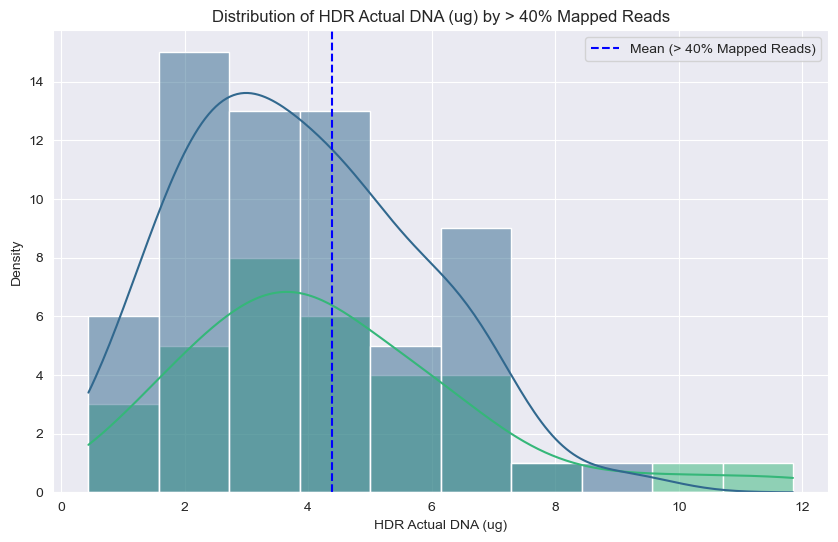

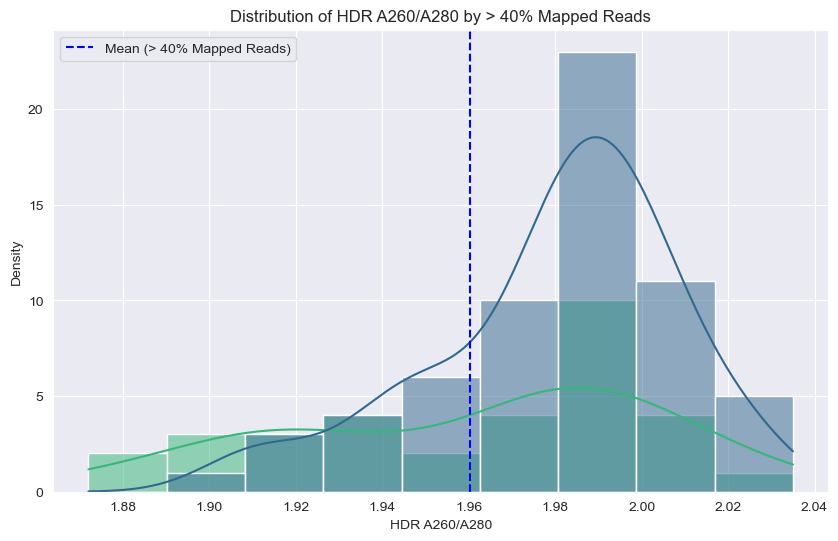

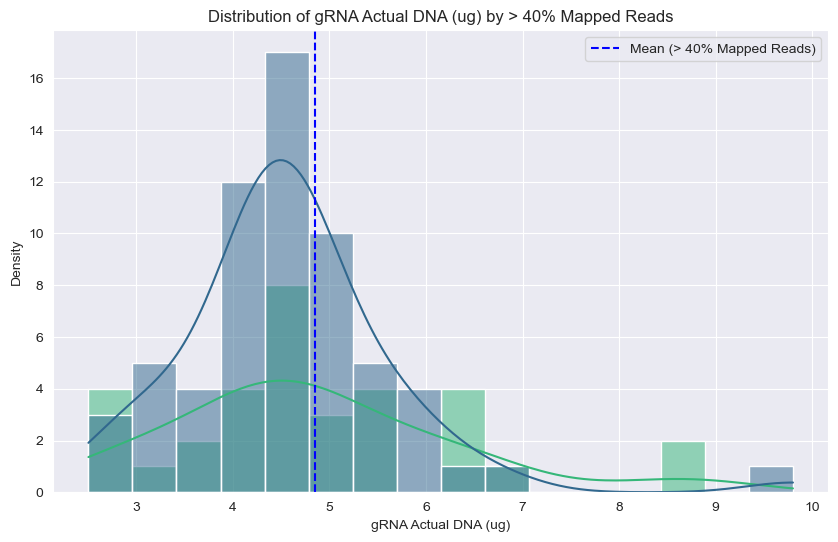

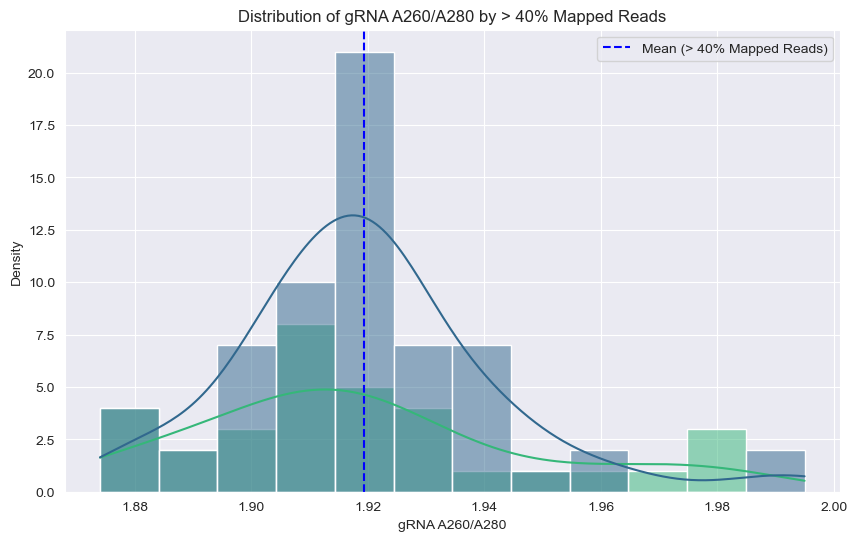

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Drop rows with missing average mapped reads
filtered_df = df.dropna(subset=['Average_mapped_reads'])

# Separate HDR and gRNA data
filtered_hdr_df = filtered_df.dropna(subset=['HDR_actual_DNA', 'HDR_A260/A280', 'Qubit(ng/ul)'])
filtered_grna_df = filtered_df.dropna(subset=['gRNA_actual_DNA', 'gRNA_A260/A280', 'gRNA_Qubit (ng/ul)'])

# Creating a binary label for > 40% mapped reads
filtered_hdr_df['> 40% Mapped Reads'] = (filtered_hdr_df['Average_mapped_reads'] > 40).astype(int)
filtered_grna_df['> 40% Mapped Reads'] = (filtered_grna_df['Average_mapped_reads'] > 40).astype(int)

# Plot 1: Distribution of HDR Actual DNA
plt.figure(figsize=(10, 6))
sns.histplot(data=filtered_hdr_df, x='HDR_actual_DNA', hue='> 40% Mapped Reads', kde=True, palette='viridis')
plt.axvline(x=filtered_hdr_df[filtered_hdr_df['> 40% Mapped Reads'] == 1]['HDR_actual_DNA'].mean(), color='blue', linestyle='--', label='Mean (> 40% Mapped Reads)')
plt.title("Distribution of HDR Actual DNA (ug) by > 40% Mapped Reads")
plt.xlabel("HDR Actual DNA (ug)")
plt.ylabel("Density")
plt.legend()
plt.show()

# Plot 2: Distribution of HDR A260/A280
plt.figure(figsize=(10, 6))
sns.histplot(data=filtered_hdr_df, x='HDR_A260/A280', hue='> 40% Mapped Reads', kde=True, palette='viridis')
plt.axvline(x=filtered_hdr_df[filtered_hdr_df['> 40% Mapped Reads'] == 1]['HDR_A260/A280'].mean(), color='blue', linestyle='--', label='Mean (> 40% Mapped Reads)')
plt.title("Distribution of HDR A260/A280 by > 40% Mapped Reads")
plt.xlabel("HDR A260/A280")
plt.ylabel("Density")
plt.legend()
plt.show()

# Plot 3: Distribution of gRNA Actual DNA
plt.figure(figsize=(10, 6))
sns.histplot(data=filtered_grna_df, x='gRNA_actual_DNA', hue='> 40% Mapped Reads', kde=True, palette='viridis')
plt.axvline(x=filtered_grna_df[filtered_grna_df['> 40% Mapped Reads'] == 1]['gRNA_actual_DNA'].mean(), color='blue', linestyle='--', label='Mean (> 40% Mapped Reads)')
plt.title("Distribution of gRNA Actual DNA (ug) by > 40% Mapped Reads")
plt.xlabel("gRNA Actual DNA (ug)")
plt.ylabel("Density")
plt.legend()
plt.show()

# Plot 4: Distribution of gRNA A260/A280
plt.figure(figsize=(10, 6))
sns.histplot(data=filtered_grna_df, x='gRNA_A260/A280', hue='> 40% Mapped Reads', kde=True, palette='viridis')
plt.axvline(x=filtered_grna_df[filtered_grna_df['> 40% Mapped Reads'] == 1]['gRNA_A260/A280'].mean(), color='blue', linestyle='--', label='Mean (> 40% Mapped Reads)')
plt.title("Distribution of gRNA A260/A280 by > 40% Mapped Reads")
plt.xlabel("gRNA A260/A280")
plt.ylabel("Density")
plt.legend()
plt.show()

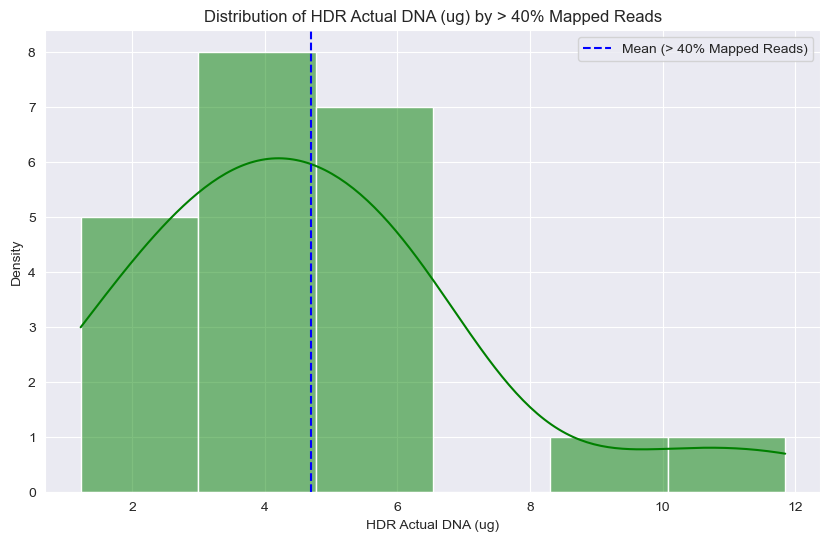

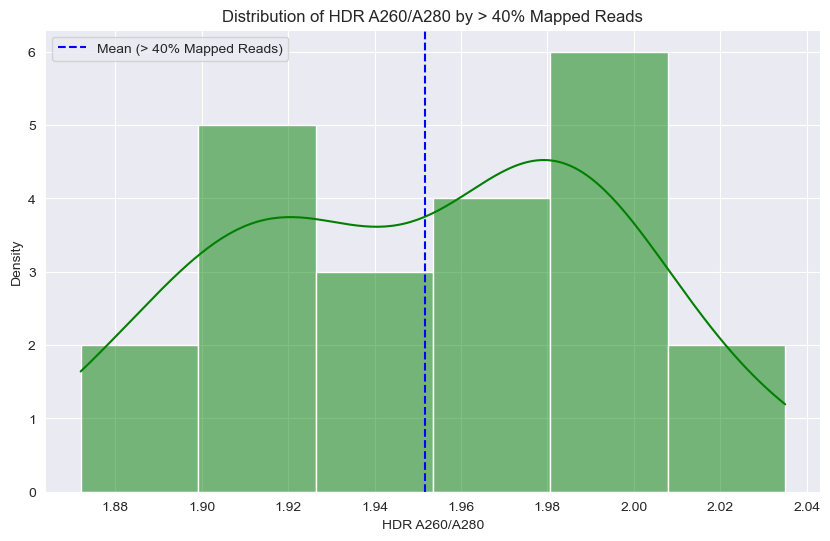

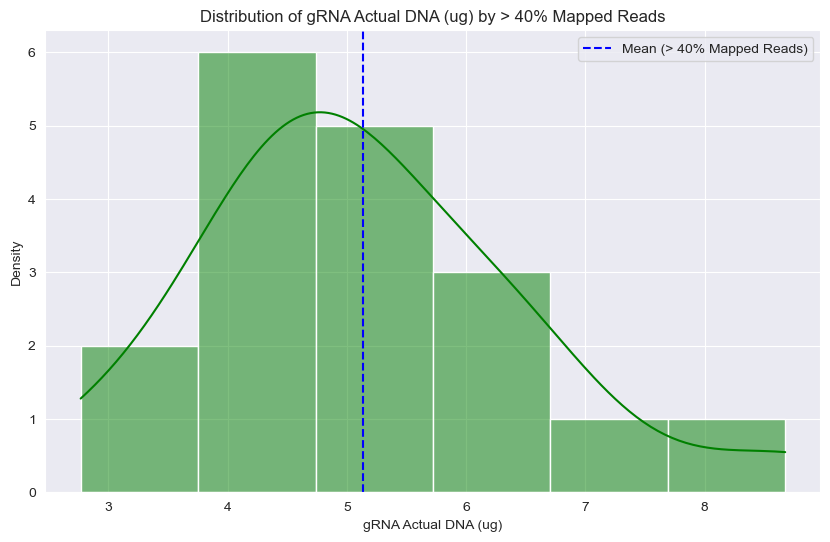

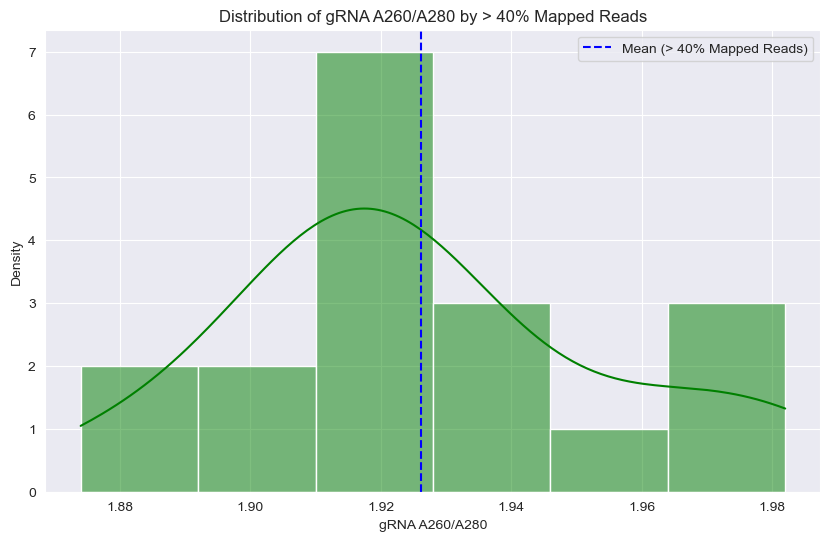

In [140]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Drop rows with missing average mapped reads
filtered_df = df.dropna(subset=['Average_mapped_reads'])

# Separate HDR and gRNA data
filtered_hdr_df = filtered_df.dropna(subset=['HDR_actual_DNA', 'HDR_A260/A280', 'Qubit(ng/ul)'])
filtered_grna_df = filtered_df.dropna(subset=['gRNA_actual_DNA', 'gRNA_A260/A280', 'gRNA_Qubit (ng/ul)'])

# Filter only rows with > 40% mapped reads
filtered_hdr_pass = filtered_hdr_df[filtered_hdr_df['Average_mapped_reads'] > 40]
filtered_grna_pass = filtered_grna_df[filtered_grna_df['Average_mapped_reads'] > 40]

# Plot 1: Distribution of HDR Actual DNA (Pass > 40%)
plt.figure(figsize=(10, 6))
sns.histplot(data=filtered_hdr_pass, x='HDR_actual_DNA', kde=True, color='green')
plt.axvline(x=filtered_hdr_pass['HDR_actual_DNA'].mean(), color='blue', linestyle='--', label='Mean (> 40% Mapped Reads)')
plt.title("Distribution of HDR Actual DNA (ug) by > 40% Mapped Reads")
plt.xlabel("HDR Actual DNA (ug)")
plt.ylabel("Density")
plt.legend()
plt.show()

# Plot 2: Distribution of HDR A260/A280 (Pass > 40%)
plt.figure(figsize=(10, 6))
sns.histplot(data=filtered_hdr_pass, x='HDR_A260/A280', kde=True, color='green')
plt.axvline(x=filtered_hdr_pass['HDR_A260/A280'].mean(), color='blue', linestyle='--', label='Mean (> 40% Mapped Reads)')
plt.title("Distribution of HDR A260/A280 by > 40% Mapped Reads")
plt.xlabel("HDR A260/A280")
plt.ylabel("Density")
plt.legend()
plt.show()

# Plot 3: Distribution of gRNA Actual DNA (Pass > 40%)
plt.figure(figsize=(10, 6))
sns.histplot(data=filtered_grna_pass, x='gRNA_actual_DNA', kde=True, color='green')
plt.axvline(x=filtered_grna_pass['gRNA_actual_DNA'].mean(), color='blue', linestyle='--', label='Mean (> 40% Mapped Reads)')
plt.title("Distribution of gRNA Actual DNA (ug) by > 40% Mapped Reads")
plt.xlabel("gRNA Actual DNA (ug)")
plt.ylabel("Density")
plt.legend()
plt.show()

# Plot 4: Distribution of gRNA A260/A280 (Pass > 40%)
plt.figure(figsize=(10, 6))
sns.histplot(data=filtered_grna_pass, x='gRNA_A260/A280', kde=True, color='green')
plt.axvline(x=filtered_grna_pass['gRNA_A260/A280'].mean(), color='blue', linestyle='--', label='Mean (> 40% Mapped Reads)')
plt.title("Distribution of gRNA A260/A280 by > 40% Mapped Reads")
plt.xlabel("gRNA A260/A280")
plt.ylabel("Density")
plt.legend()
plt.show()



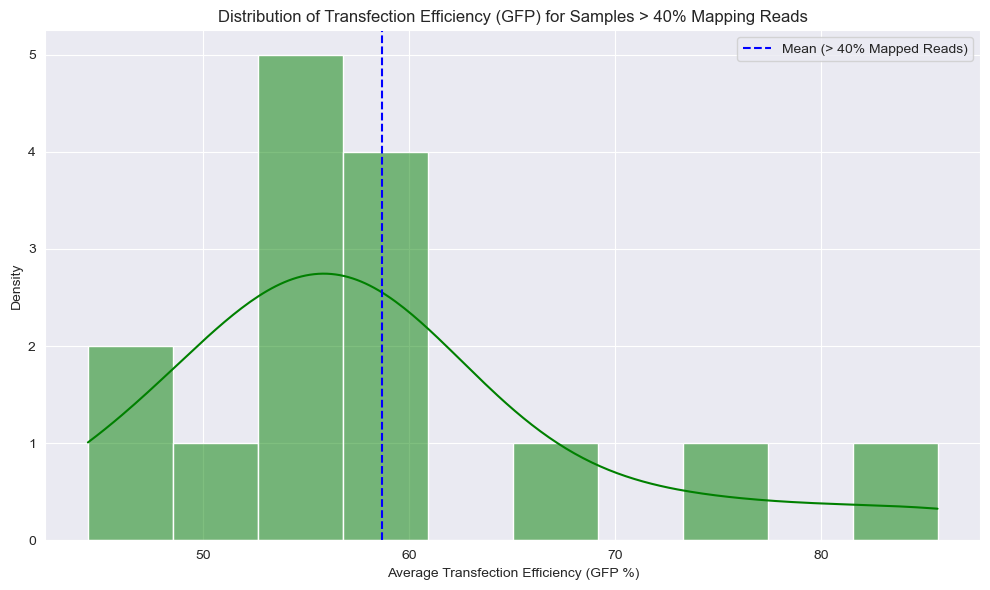

In [168]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the updated master file
file_path = '/Users/ds39/Documents/Sunny/MAVE/RD/concentration/250409_AllTargetonlist_transfectionEffi.csv'
df = pd.read_csv(file_path)

# Drop rows with missing mapping reads or transfection efficiency
filtered_df = df.dropna(subset=['Average_mapped_reads', 'Average_TransfectionEfficency_GFP'])

# Filter to only samples with > 40% average mapped reads
filtered_pass = filtered_df[filtered_df['Average_mapped_reads'] > 40]

# Plot: Distribution of Transfection Efficiency for > 40% Mapping
plt.figure(figsize=(10, 6))
sns.histplot(data=filtered_pass, x='Average_TransfectionEfficency_GFP', kde=True, color='green')
plt.axvline(x=filtered_pass['Average_TransfectionEfficency_GFP'].mean(), color='blue', linestyle='--', label='Mean (> 40% Mapped Reads)')
plt.title("Distribution of Transfection Efficiency (GFP) for Samples > 40% Mapping Reads")
plt.xlabel("Average Transfection Efficiency (GFP %)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


/var/folders/88/r4q5_g595xs0mq3119k4nxy40000gq/T/ipykernel_52911/3472004829.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_hdr_df['Mapping Result'] = filtered_hdr_df['Average_mapped_reads'].apply(lambda x: 'Pass' if x > 40 else 'Fail')


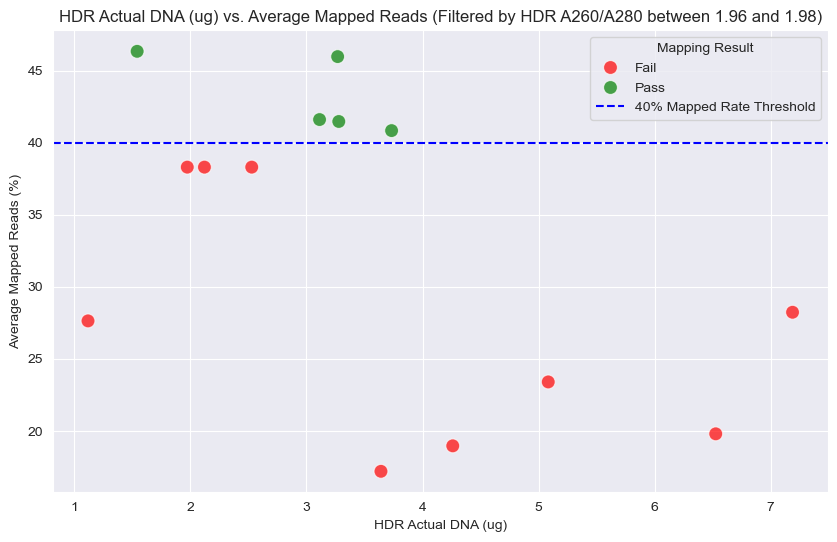

In [109]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Filter the DataFrame for samples with HDR A260/A280 between 1.96 and 1.98
filtered_hdr_df = filtered_df[
    (filtered_df['HDR_A260/A280'] >= 1.96) & 
    (filtered_df['HDR_A260/A280'] <= 1.98)
]

# Create a new column to label whether the sample achieved >40% mapped reads
filtered_hdr_df['Mapping Result'] = filtered_hdr_df['Average_mapped_reads'].apply(lambda x: 'Pass' if x > 40 else 'Fail')

# Plot: HDR Actual DNA (ug) vs. Average Mapped Reads with Coloring for Success
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=filtered_hdr_df,
    x='HDR_actual_DNA',
    y='Average_mapped_reads',
    hue='Mapping Result',
    palette={'Fail': "red", 'Pass': "green"},
    alpha=0.7,
    s=100
)
plt.axhline(40, color='blue', linestyle='--', label='40% Mapped Rate Threshold')
plt.title("HDR Actual DNA (ug) vs. Average Mapped Reads (Filtered by HDR A260/A280 between 1.96 and 1.98)")
plt.xlabel("HDR Actual DNA (ug)")
plt.ylabel("Average Mapped Reads (%)")
plt.legend(title='Mapping Result', loc='upper right')
plt.show()



/var/folders/88/r4q5_g595xs0mq3119k4nxy40000gq/T/ipykernel_52911/2098116493.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_filtered_df['Mapping Result'] = combined_filtered_df['Average_mapped_reads'].apply(lambda x: 'Pass' if x > 40 else 'Fail')


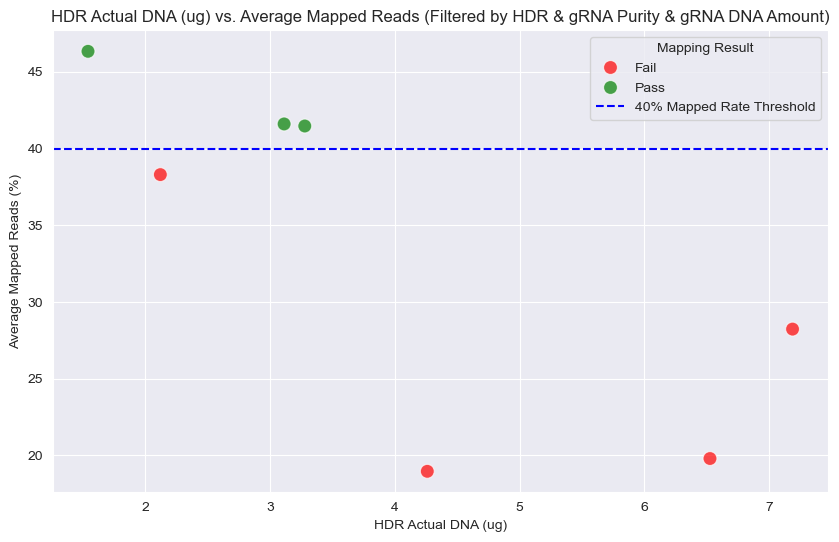

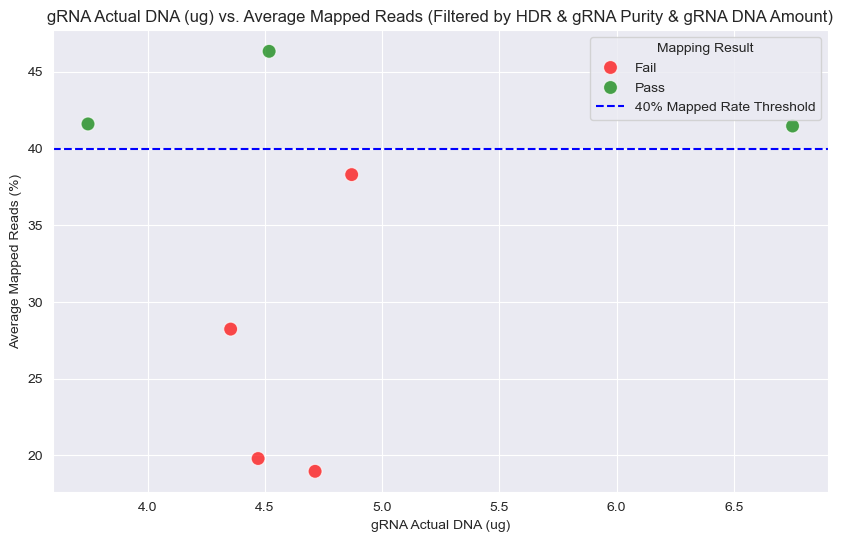

In [116]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Drop rows with missing average mapped reads
filtered_df = df.dropna(subset=['Average_mapped_reads'])

# Filter the DataFrame for desired purity and gRNA DNA amount ranges
combined_filtered_df = filtered_df[
    (filtered_df['HDR_A260/A280'] >= 1.96) & 
    (filtered_df['HDR_A260/A280'] <= 1.98) & 
    (filtered_df['gRNA_A260/A280'] >= 1.91) & 
    (filtered_df['gRNA_A260/A280'] <= 1.93)  
    #(filtered_df['gRNA_actual_DNA'] >= 4) & 
    #(filtered_df['gRNA_actual_DNA'] <= 6)
]

# Create a new column to label whether the sample achieved >40% mapped reads
combined_filtered_df['Mapping Result'] = combined_filtered_df['Average_mapped_reads'].apply(lambda x: 'Pass' if x > 40 else 'Fail')

# Plot 1: HDR Actual DNA (ug) vs. Average Mapped Reads (Filtered by HDR & gRNA Purity Range & gRNA DNA amount)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=combined_filtered_df,
    x='HDR_actual_DNA',
    y='Average_mapped_reads',
    hue='Mapping Result',
    palette={'Fail': "red", 'Pass': "green"},
    alpha=0.7,
    s=100
)
plt.axhline(40, color='blue', linestyle='--', label='40% Mapped Rate Threshold')
plt.title("HDR Actual DNA (ug) vs. Average Mapped Reads (Filtered by HDR & gRNA Purity & gRNA DNA Amount)")
plt.xlabel("HDR Actual DNA (ug)")
plt.ylabel("Average Mapped Reads (%)")
plt.legend(title='Mapping Result', loc='upper right')
plt.show()

# Plot 2: gRNA Actual DNA (ug) vs. Average Mapped Reads (Filtered by HDR & gRNA Purity Range & gRNA DNA amount)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=combined_filtered_df,
    x='gRNA_actual_DNA',
    y='Average_mapped_reads',
    hue='Mapping Result',
    palette={'Fail': "red", 'Pass': "green"},
    alpha=0.7,
    s=100
)
plt.axhline(40, color='blue', linestyle='--', label='40% Mapped Rate Threshold')
plt.title("gRNA Actual DNA (ug) vs. Average Mapped Reads (Filtered by HDR & gRNA Purity & gRNA DNA Amount)")
plt.xlabel("gRNA Actual DNA (ug)")
plt.ylabel("Average Mapped Reads (%)")
plt.legend(title='Mapping Result', loc='upper right')
plt.show()


/var/folders/88/r4q5_g595xs0mq3119k4nxy40000gq/T/ipykernel_52911/2238350002.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_eff_df['Mapping Result'] = filtered_eff_df['Average_mapped_reads'].apply(lambda x: 'Pass' if x > 40 else 'Fail')


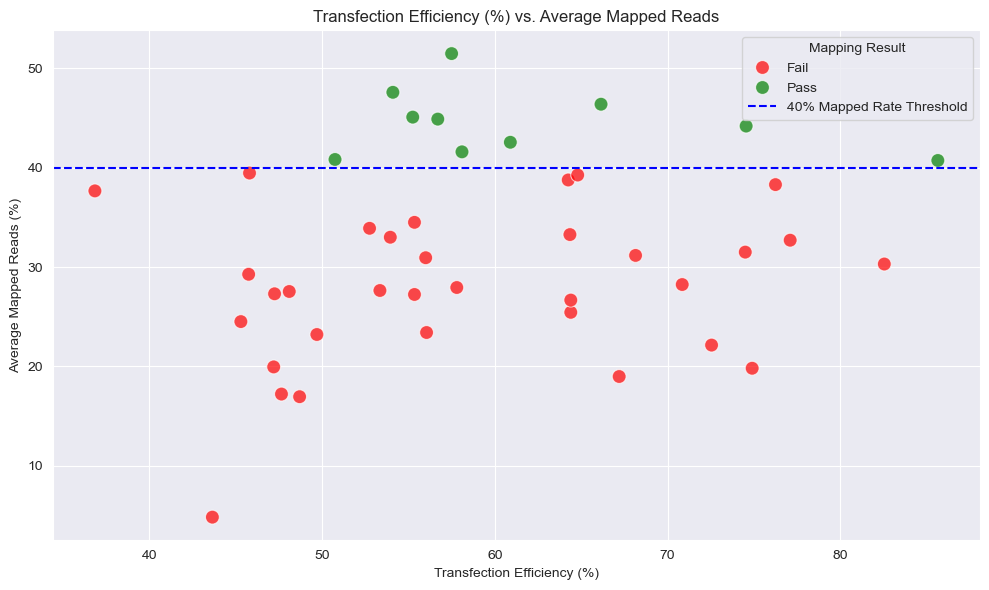

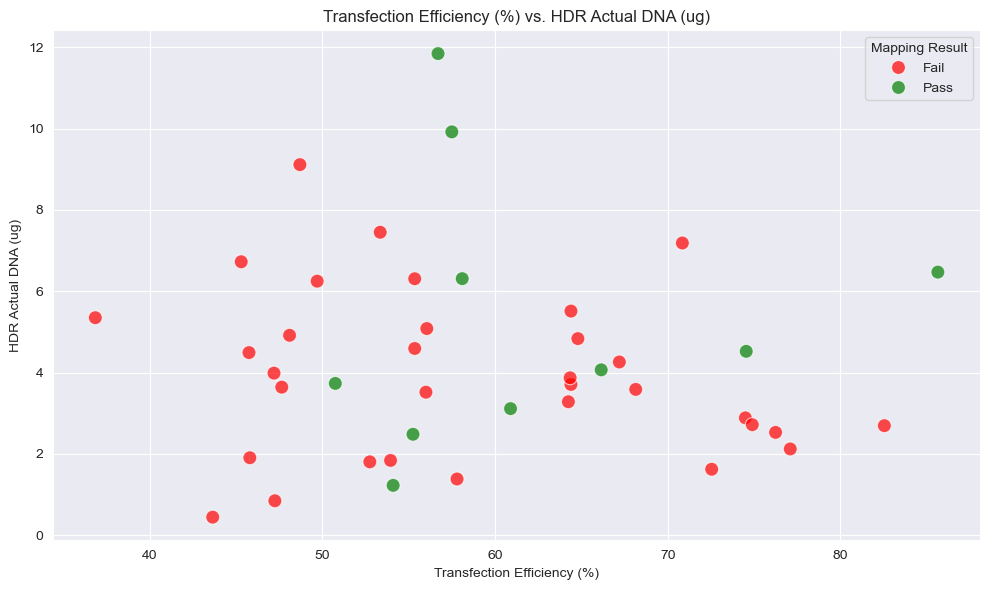

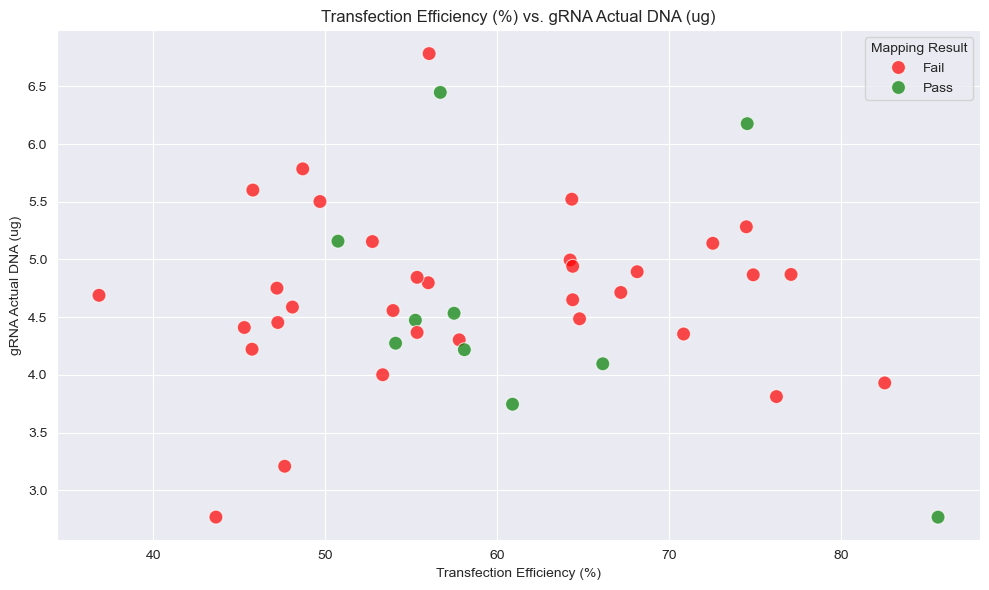

In [172]:
# Re-importing necessary libraries due to code execution state reset
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Load the cleaned master file
file_path = "/Users/ds39/Documents/Sunny/MAVE/RD/concentration/250409_AllTargetonlist_transfectionEffi.csv"
df = pd.read_csv(file_path)

# Drop rows with missing necessary data for all three plots
filtered_eff_df = df.dropna(subset=[
    'Average_TransfectionEfficency_GFP', 
    'Average_mapped_reads',
    'HDR_actual_DNA',
    'gRNA_actual_DNA'
])

# Create pass/fail labels based on mapping threshold
filtered_eff_df['Mapping Result'] = filtered_eff_df['Average_mapped_reads'].apply(lambda x: 'Pass' if x > 40 else 'Fail')

# Plot 1: Transfection Efficiency vs. Average Mapped Reads
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=filtered_eff_df,
    x='Average_TransfectionEfficency_GFP',
    y='Average_mapped_reads',
    hue='Mapping Result',
    palette={'Fail': 'red', 'Pass': 'green'},
    s=100,
    alpha=0.7
)
plt.axhline(40, color='blue', linestyle='--', label='40% Mapped Rate Threshold')
plt.title("Transfection Efficiency (%) vs. Average Mapped Reads")
plt.xlabel("Transfection Efficiency (%)")
plt.ylabel("Average Mapped Reads (%)")
plt.legend(title='Mapping Result', loc='upper right')
plt.tight_layout()
plt.show()

# Plot 2: Transfection Efficiency vs. HDR Actual DNA
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=filtered_eff_df,
    x='Average_TransfectionEfficency_GFP',
    y='HDR_actual_DNA',
    hue='Mapping Result',
    palette={'Fail': 'red', 'Pass': 'green'},
    s=100,
    alpha=0.7
)
plt.title("Transfection Efficiency (%) vs. HDR Actual DNA (ug)")
plt.xlabel("Transfection Efficiency (%)")
plt.ylabel("HDR Actual DNA (ug)")
plt.legend(title='Mapping Result', loc='upper right')
plt.tight_layout()
plt.show()

# Plot 3: Transfection Efficiency vs. gRNA Actual DNA
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=filtered_eff_df,
    x='Average_TransfectionEfficency_GFP',
    y='gRNA_actual_DNA',
    hue='Mapping Result',
    palette={'Fail': 'red', 'Pass': 'green'},
    s=100,
    alpha=0.7
)
plt.title("Transfection Efficiency (%) vs. gRNA Actual DNA (ug)")
plt.xlabel("Transfection Efficiency (%)")
plt.ylabel("gRNA Actual DNA (ug)")
plt.legend(title='Mapping Result', loc='upper right')
plt.tight_layout()
plt.show()



/var/folders/88/r4q5_g595xs0mq3119k4nxy40000gq/T/ipykernel_52911/191446779.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_filtered_df['Mapping Result'] = combined_filtered_df['Average_mapped_reads'].apply(lambda x: 1 if x > 40 else 0)
/var/folders/88/r4q5_g595xs0mq3119k4nxy40000gq/T/ipykernel_52911/191446779.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')


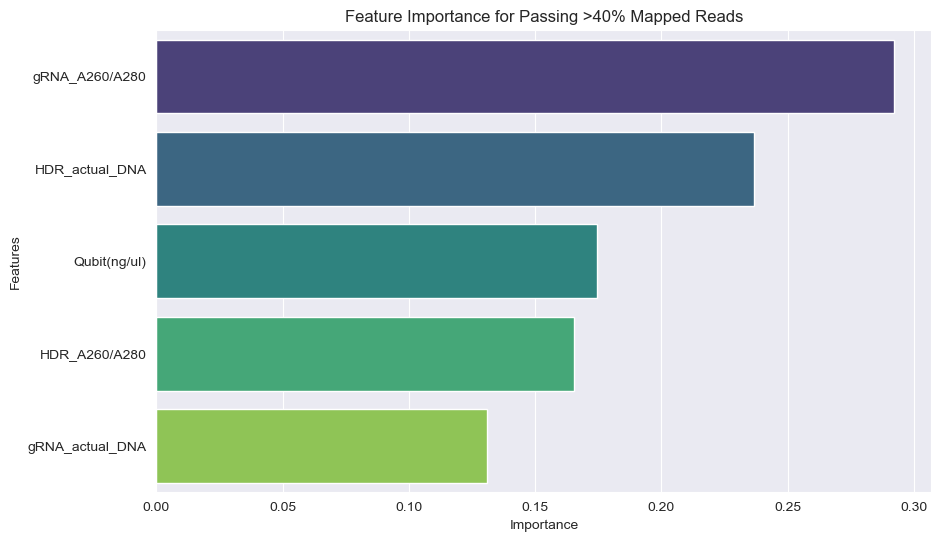

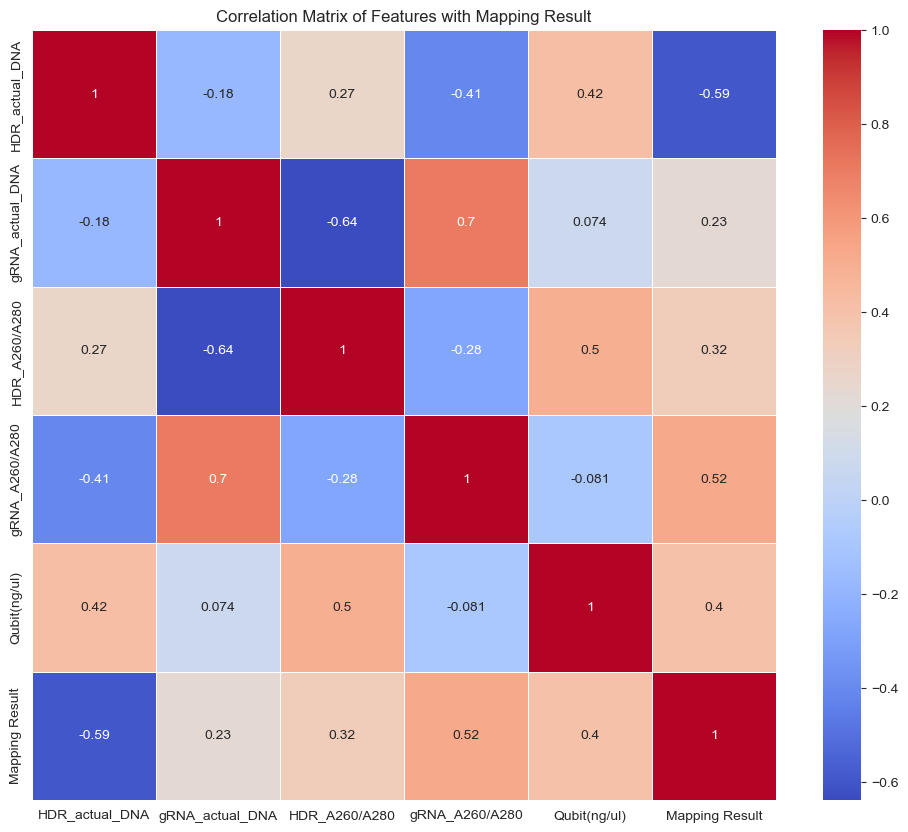

In [123]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

# Drop rows with missing average mapped reads
filtered_df = df.dropna(subset=['Average_mapped_reads'])

# Filter the DataFrame for desired purity and gRNA DNA amount ranges
combined_filtered_df = filtered_df[
    (filtered_df['HDR_A260/A280'] >= 1.96) & 
    (filtered_df['HDR_A260/A280'] <= 1.98) & 
    (filtered_df['gRNA_A260/A280'] >= 1.91) & 
    (filtered_df['gRNA_A260/A280'] <= 1.93)
]

# Label Pass or Fail based on the threshold
combined_filtered_df['Mapping Result'] = combined_filtered_df['Average_mapped_reads'].apply(lambda x: 1 if x > 40 else 0)

# Select relevant features for analysis
features = [
    'HDR_actual_DNA', 'gRNA_actual_DNA', 'HDR_A260/A280', 'gRNA_A260/A280', 
    'Qubit(ng/ul)'
]

X = combined_filtered_df[features]
y = combined_filtered_df['Mapping Result']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train a Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_scaled, y)

# Get feature importances
importances = model.feature_importances_
feature_importance = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Display feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title("Feature Importance for Passing >40% Mapped Reads")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

# Display correlation matrix
correlation_matrix = combined_filtered_df[features + ['Mapping Result']].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=.5)
plt.title("Correlation Matrix of Features with Mapping Result")
plt.show()


        Sample  Pre_nanodrop, ng/ul  Pre_A260/280  Pre_A260/230  \
0  HDOI_hdr520               1312.8         2.006         2.614   
1  HUKW_hdr447               1049.9         2.004         2.706   
2  NQBU_hdr469               2985.1         1.984         2.651   
3  NBXL_hdr467               2694.0         2.004         2.658   
4  AXFG_hdr500               4360.0         1.948         2.563   

   Pre_Qubit, ng/ul  Post_nanodrop, ng/ul  Post_A260/280  Post_A260/230  \
0               402                1941.4          1.899          2.385   
1               202                1352.5          1.903          2.407   
2               366                1749.5          1.912          2.341   
3               324                1716.5          1.907          2.363   
4               246                1827.2          1.917          2.342   

   Post_Qubit, ng/ul  Mapping reads  
0               1730           62.8  
1               1110           71.6  
2               1440           5

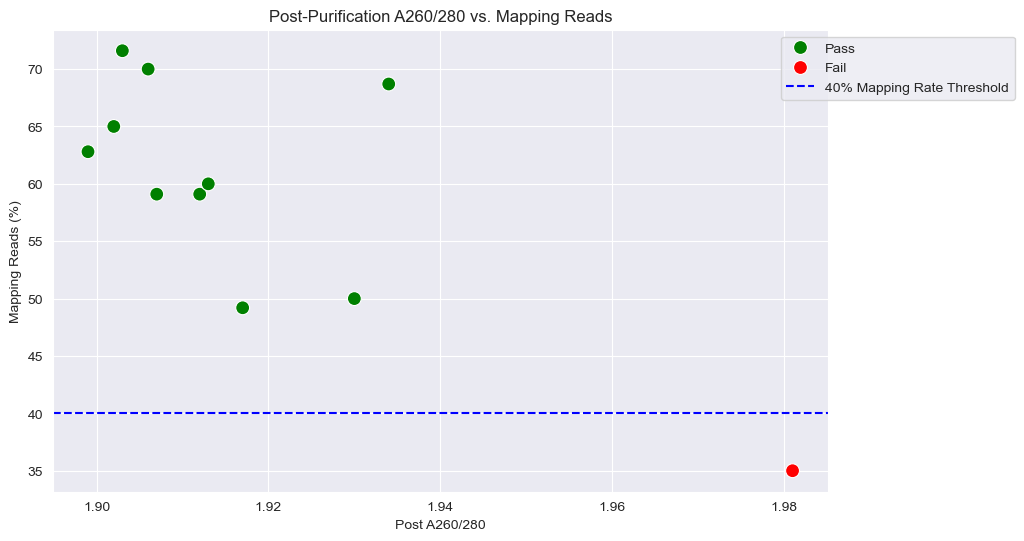

In [130]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Load your CSV file
file_path = '/Users/ds39/Documents/Sunny/MAVE/RD/concentration/RecentScreen_concentration.csv'
df = pd.read_csv(file_path)

# Display the first few rows to understand the structure
print(df.head())

# Rename columns to make them easier to access
df.columns = ['Sample', 'Pre_nanodrop', 'Pre_A260/280', 'Pre_A260/230', 'Pre_Qubit', 
              'Post_nanodrop', 'Post_A260/280', 'Post_A260/230', 'Post_Qubit', 
              'Mapping_reads']

# Drop rows with missing Mapping Reads
df = df.dropna(subset=['Mapping_reads'])

# Convert Mapping Reads to numeric (if it's not already)
df['Mapping_reads'] = pd.to_numeric(df['Mapping_reads'], errors='coerce')

# Create a column to classify samples as 'Pass' or 'Fail'
df['Mapping_Result'] = df['Mapping_reads'].apply(lambda x: 'Pass' if x > 40 else 'Fail')

# Plot: Post-Purification A260/280 vs Mapping Reads
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Post_A260/280', y='Mapping_reads', hue='Mapping_Result', palette={'Fail': 'red', 'Pass': 'green'}, s=100)
plt.axhline(40, color='blue', linestyle='--', label='40% Mapping Rate Threshold')
plt.title('Post-Purification A260/280 vs. Mapping Reads')
plt.xlabel('Post A260/280')
plt.ylabel('Mapping Reads (%)')
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
plt.show()



/var/folders/88/r4q5_g595xs0mq3119k4nxy40000gq/T/ipykernel_52911/121313777.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_hdr_df['Mapping_Result'] = filtered_hdr_df['Average_mapped_reads'].apply(lambda x: 'Pass' if x > 40 else 'Fail')


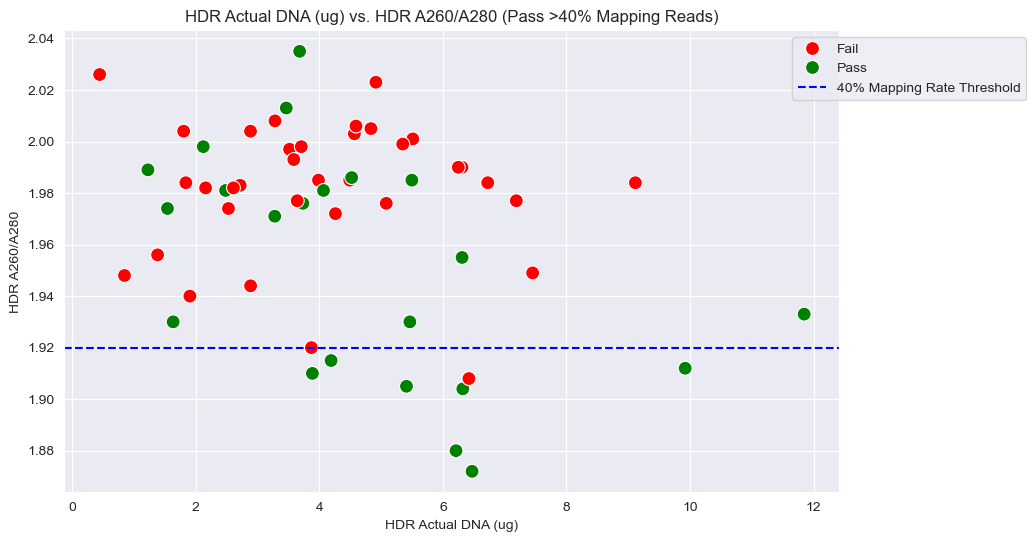

In [141]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Load your Excel file
file_path = '/Users/ds39/Documents/Sunny/MAVE/RD/concentration/250402_AllTargetonlist_quantification_revalues.xlsx'
df = pd.read_excel(file_path, engine='openpyxl')

# Drop rows with missing HDR_actual_DNA, HDR_A260/A280, or Average_mapped_reads
filtered_hdr_df = df.dropna(subset=['HDR_actual_DNA', 'HDR_A260/A280', 'Average_mapped_reads'])

# Create a column to classify samples as 'Pass' or 'Fail'
filtered_hdr_df['Mapping_Result'] = filtered_hdr_df['Average_mapped_reads'].apply(lambda x: 'Pass' if x > 40 else 'Fail')

# Plot: HDR_actual_DNA vs. HDR A260/A280, color-coded by mapping result
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=filtered_hdr_df,
    x='HDR_actual_DNA',
    y='HDR_A260/A280',
    hue='Mapping_Result',
    palette={'Pass': 'green', 'Fail': 'red'},
    s=100
)

# Add a horizontal line at 40% Average_mapped_reads
plt.axhline(1.92, color='blue', linestyle='--', label='40% Mapping Rate Threshold')

plt.title('HDR Actual DNA (ug) vs. HDR A260/A280 (Pass >40% Mapping Reads)')
plt.xlabel('HDR Actual DNA (ug)')
plt.ylabel('HDR A260/A280')
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
plt.show()




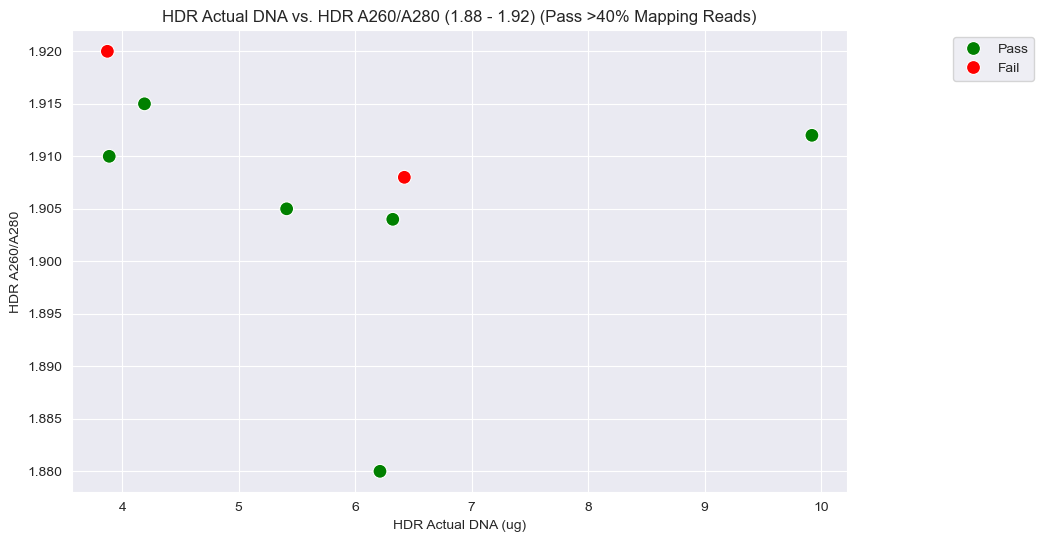

In [138]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Load your Excel file
file_path = '/Users/ds39/Documents/Sunny/MAVE/RD/concentration/250402_AllTargetonlist_quantification_revalues.xlsx'
df = pd.read_excel(file_path, engine='openpyxl')

# Drop rows with missing HDR_actual_DNA, HDR_A260/A280, or Average_mapped_reads
filtered_hdr_df = df.dropna(subset=['HDR_actual_DNA', 'HDR_A260/A280', 'Average_mapped_reads'])

# Filter the DataFrame for HDR A260/A280 between 1.88 and 1.92
filtered_hdr_df = filtered_hdr_df[(filtered_hdr_df['HDR_A260/A280'] >= 1.88) & (filtered_hdr_df['HDR_A260/A280'] <= 1.92)]

# Create a column to classify samples as 'Pass' or 'Fail'
filtered_hdr_df['Mapping_Result'] = filtered_hdr_df['Average_mapped_reads'].apply(lambda x: 'Pass' if x > 40 else 'Fail')

# Plot: HDR_actual_DNA vs. HDR A260/A280, color-coded by mapping result
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=filtered_hdr_df,
    x='HDR_actual_DNA',
    y='HDR_A260/A280',
    hue='Mapping_Result',
    palette={'Pass': 'green', 'Fail': 'red'},
    s=100
)
plt.title('HDR Actual DNA vs. HDR A260/A280 (1.88 - 1.92) (Pass >40% Mapping Reads)')
plt.xlabel('HDR Actual DNA (ug)')
plt.ylabel('HDR A260/A280')
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
plt.show()
